# HuggingFace Text Classification — Variability Study

Transformer fine-tuning is famously seed-sensitive. Small differences in random initialization can land two runs in different optimization basins, producing final accuracies that differ by several percentage points on small datasets. This is the phenomenon Mosbach et al. (2021) documented on GLUE and that Ictonyx's `HuggingFaceModelWrapper` is built to measure.

This notebook runs a variability study on a tiny BERT model for text classification — small enough to finish in a reasonable time on consumer hardware, large enough to exhibit the training-stochastic variance that matters for the paper-scale studies. After it runs, we look at the distribution of test accuracies, inspect the epoch-level trajectories, and use `plot_paired_deltas()` to show what a winner-reverses comparison looks like on real transformer data.

**Requirements:** `pip install 'ictonyx[huggingface]' datasets`

**Compute note:** This notebook runs 5 fine-tuning jobs of a 2-layer BERT-like model on a 500-example subset of AG News. On a single consumer GPU it takes ~5-10 minutes total. On CPU it's ~30-45 minutes. The model and dataset sizes are chosen to keep the notebook self-contained; for paper-quality results you'd want the full AG News training set and a larger model.

In [1]:
#!pip install 'ictonyx[huggingface]' datasets -q

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import ictonyx as ix
from ictonyx import HuggingFaceModelWrapper

from datasets import load_dataset

print(f'Ictonyx {ix.__version__}')
print(f'PyTorch {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

Ictonyx 0.4.6
PyTorch 2.10.0+cu128
CUDA available: True


## Data: AG News subset

AG News is a four-class news topic classification dataset (World, Sports, Business, Sci/Tech). The full training set has 120,000 examples; for this notebook we use a 500-example balanced subset plus a 500-example test set. This is small enough that per-run fine-tuning is fast, but large enough that the model actually learns something non-trivial and variance across seeds is visible.

In [4]:
ds = load_dataset('ag_news')

# Subsample train and test to keep runtime modest
rng = np.random.default_rng(42)
train_idx = rng.choice(len(ds['train']), size=500, replace=False).tolist()
test_idx = rng.choice(len(ds['test']), size=500, replace=False).tolist()

train_texts = [ds['train'][int(i)]['text'] for i in train_idx]
train_labels = [ds['train'][int(i)]['label'] for i in train_idx]
test_texts = [ds['test'][int(i)]['text'] for i in test_idx]
test_labels = [ds['test'][int(i)]['label'] for i in test_idx]

print(f'Train: {len(train_texts)} examples')
print(f'Test:  {len(test_texts)} examples')
print(f'Classes: {sorted(set(train_labels))}  (0=World, 1=Sports, 2=Business, 3=Sci/Tech)')
print(f'\nClass balance (train):')
for c in range(4):
    print(f'  Class {c}: {train_labels.count(c)}')

Train: 500 examples
Test:  500 examples
Classes: [0, 1, 2, 3]  (0=World, 1=Sports, 2=Business, 3=Sci/Tech)

Class balance (train):
  Class 0: 109
  Class 1: 130
  Class 2: 131
  Class 3: 130


## The model

`google/bert_uncased_L-2_H-128_A-2` is a tiny BERT variant: 2 transformer layers, 128 hidden dimensions, 2 attention heads. It's the same model Ictonyx uses in its own test suite, chosen for fast fine-tuning while still being recognizably a transformer. Real research-scale work would use `bert-base-uncased` (12 layers, 768 hidden) or `distilbert-base-uncased` (6 layers, 768 hidden) — we'll stay small here for speed.

Thanks to the `_build_from_class` fix in v0.4.5 (X-3), we can pass `HuggingFaceModelWrapper` directly to `variability_study()` with constructor kwargs — no lambda required.

In [5]:
MODEL_NAME = 'google/bert_uncased_L-2_H-128_A-2'
NUM_LABELS = 4

## The variability study

5 runs is on the low end of what you'd want for statistical claims — the CI is still wide at N=5 — but is enough to see the shape of the distribution and confirm the infrastructure works end-to-end. For the paper-scale version of this experiment, you'd run N=20.

`HuggingFaceModelWrapper` handles tokenization internally; we just hand it texts and labels. The `epochs`, `batch_size`, and `learning_rate` kwargs flow through to the underlying `transformers.Trainer`.

In [6]:
def build_hf_tiny(config):
    return HuggingFaceModelWrapper(
        model_name_or_path=MODEL_NAME,
        num_labels=NUM_LABELS,
    )

results = ix.variability_study(
    model=build_hf_tiny,
    data=(train_texts, train_labels),
    validation_data=(test_texts, test_labels),
    runs=20,
    epochs=12,
    batch_size=16,
    learning_rate=5e-5,
    seed=2026,
)

print(results.summarize())

Loading and preparing data...
Array splits - Train: 350, Val: 50, Test: 100
Data loaded successfully

Starting Variability Study
  Runs: 20
  Epochs per run: 12
  Execution mode: in standard mode
  Seed: 2026



Variability Study:   0%| | 0

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

{'eval_loss': '1.377', 'eval_accuracy': '0.3', 'eval_runtime': '0.0185', 'eval_samples_per_second': '2703', 'eval_steps_per_second': '216.3', 'epoch': '1'}
{'eval_loss': '1.351', 'eval_accuracy': '0.38', 'eval_runtime': '0.0127', 'eval_samples_per_second': '3925', 'eval_steps_per_second': '314', 'epoch': '2'}
{'loss': '1.384', 'grad_norm': '3.576', 'learning_rate': '1.814e-05', 'epoch': '2.273'}
{'eval_loss': '1.325', 'eval_accuracy': '0.54', 'eval_runtime': '0.0128', 'eval_samples_per_second': '3918', 'eval_steps_per_second': '313.4', 'epoch': '3'}
{'eval_loss': '1.304', 'eval_accuracy': '0.6', 'eval_runtime': '0.013', 'eval_samples_per_second': '3843', 'eval_steps_per_second': '307.4', 'epoch': '4'}
{'loss': '1.324', 'grad_norm': '2.177', 'learning_rate': '1.392e-05', 'epoch': '4.545'}
{'eval_loss': '1.286', 'eval_accuracy': '0.66', 'eval_runtime': '0.012', 'eval_samples_per_second': '4158', 'eval_steps_per_second': '332.6', 'epoch': '5'}
{'eval_loss': '1.268', 'eval_accuracy': '0.72

Variability Study:   5%| | 1

...

Variability Study:  95%|▉| 1

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

{'eval_loss': '1.397', 'eval_accuracy': '0.26', 'eval_runtime': '0.0127', 'eval_samples_per_second': '3942', 'eval_steps_per_second': '315.3', 'epoch': '1'}
{'eval_loss': '1.377', 'eval_accuracy': '0.26', 'eval_runtime': '0.0136', 'eval_samples_per_second': '3668', 'eval_steps_per_second': '293.4', 'epoch': '2'}
{'loss': '1.377', 'grad_norm': '2.789', 'learning_rate': '1.814e-05', 'epoch': '2.273'}
{'eval_loss': '1.35', 'eval_accuracy': '0.28', 'eval_runtime': '0.0139', 'eval_samples_per_second': '3588', 'eval_steps_per_second': '287', 'epoch': '3'}
{'eval_loss': '1.332', 'eval_accuracy': '0.36', 'eval_runtime': '0.0127', 'eval_samples_per_second': '3925', 'eval_steps_per_second': '314', 'epoch': '4'}
{'loss': '1.33', 'grad_norm': '2.68', 'learning_rate': '1.392e-05', 'epoch': '4.545'}
{'eval_loss': '1.313', 'eval_accuracy': '0.48', 'eval_runtime': '0.0133', 'eval_samples_per_second': '3752', 'eval_steps_per_second': '300.1', 'epoch': '5'}
{'eval_loss': '1.297', 'eval_accuracy': '0.48'

Variability Study: 100%|█| 2


--------------------------------------------------

Study Summary:
  Successful runs: 20/20
  val_loss: 1.2425 (SD = 0.0292)
  val_accuracy: 0.6350 (SD = 0.0710)
  val_runtime: 0.0136 (SD = 0.0012)
  val_samples_per_second: 3707.8819 (SD = 324.2617)
  val_steps_per_second: 296.6304 (SD = 25.9410)
  train_loss: 1.2904 (SD = 0.0179)
Variability Study Results
Successful runs: 20
Seed: 2026

Test Set Metrics:
--------------------
accuracy:
  N:                20
  Mean:             0.6470
  SD (sample, N-1): 0.0594
  SE:               0.0133
  Min:              0.5400
  Max:              0.7300

Validation Metrics:
--------------------
train_loss:
  N:                20
  Mean:             1.2904
  SD (sample, N-1): 0.0179
  SE:               0.0040
  Min:              1.2557
  Max:              1.3172
val_accuracy:
  N:                20
  Mean:             0.6350
  SD (sample, N-1): 0.0710
  SE:               0.0159
  Min:              0.5200
  Max:              0.7800
val_loss:
  N:    

In [7]:
# Look at per-run raw history, not just the aggregate
print(f"Number of runs stored: {len(results.all_runs_metrics)}")
print()
for i, run_history in enumerate(results.all_runs_metrics[:5]):
    print(f"Run {i+1} final row:")
    print(run_history.iloc[-1])
    print()

Number of runs stored: 20

Run 1 final row:
val_loss                     1.201833
val_accuracy                 0.760000
val_runtime                  0.013200
val_samples_per_second    3794.239000
val_steps_per_second       303.539000
epoch                       12.000000
train_loss                   1.272639
run_num                      1.000000
Name: 11, dtype: float64

Run 2 final row:
val_loss                     1.247309
val_accuracy                 0.520000
val_runtime                  0.012100
val_samples_per_second    4132.808000
val_steps_per_second       330.625000
epoch                       12.000000
train_loss                   1.288111
run_num                      2.000000
Name: 11, dtype: float64

Run 3 final row:
val_loss                     1.254606
val_accuracy                 0.620000
val_runtime                  0.014300
val_samples_per_second    3503.838000
val_steps_per_second       280.307000
epoch                       12.000000
train_loss                   1.300

## Looking at the distribution

Five runs is too few to draw strong conclusions, but we can look at the shape. The spread between the best and worst run is the "seed risk" on this dataset — if you trained once and reported, your number could have been anywhere in that range.

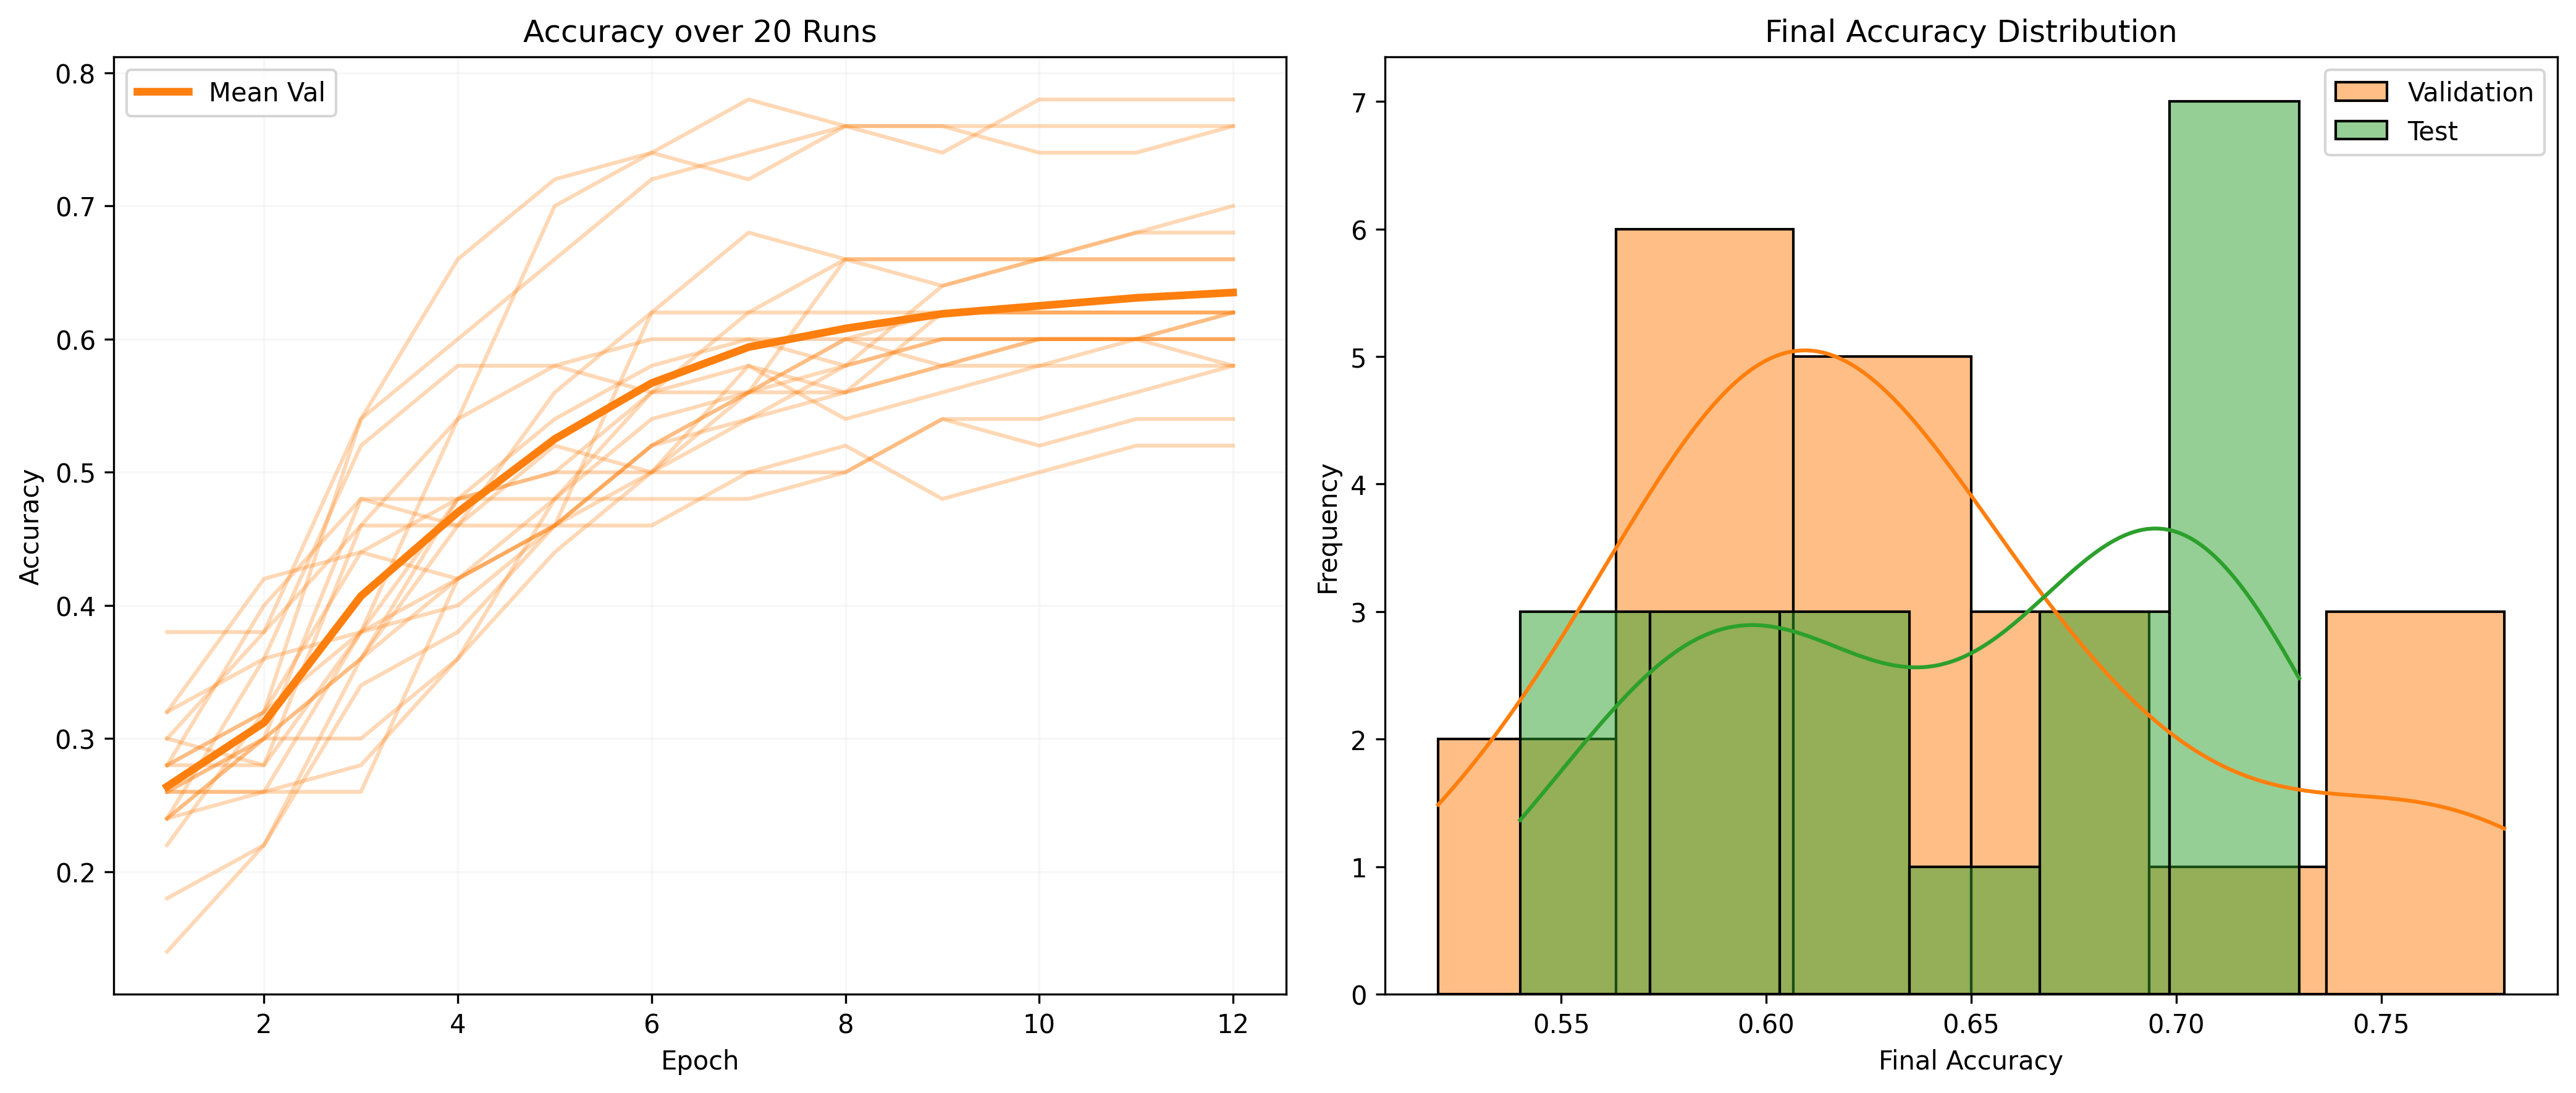

In [8]:
ix.plot_variability_summary(results=results, metric='accuracy', show=False);

## Per-run test accuracies

For the paper's argument, what matters is not just the mean but the individual runs. Here are all five.

In [9]:
test_accs = results.get_test_metric_values('accuracy')
for i, acc in enumerate(test_accs, 1):
    print(f'Run {i}: {acc:.4f}')

print(f'\nMean: {np.mean(test_accs):.4f}')
print(f'SD:   {np.std(test_accs, ddof=1):.4f}')
print(f'Range: [{min(test_accs):.4f}, {max(test_accs):.4f}]')

Run 1: 0.7100
Run 2: 0.5800
Run 3: 0.6700
Run 4: 0.6000
Run 5: 0.7000
Run 6: 0.7000
Run 7: 0.5900
Run 8: 0.7100
Run 9: 0.7100
Run 10: 0.6900
Run 11: 0.5400
Run 12: 0.6100
Run 13: 0.6100
Run 14: 0.6600
Run 15: 0.6700
Run 16: 0.7300
Run 17: 0.6200
Run 18: 0.7000
Run 19: 0.5700
Run 20: 0.5700

Mean: 0.6470
SD:   0.0594
Range: [0.5400, 0.7300]


## Epoch-level dynamics

HuggingFace runs track per-epoch metrics just like PyTorch runs do. We can see how training accuracy evolves over the 3 epochs of fine-tuning, across all 5 runs simultaneously.

The `plot_run_trajectories()` plotter defaults to `val_accuracy` per the epoch-context behavior added in v0.4.6 (X-6).

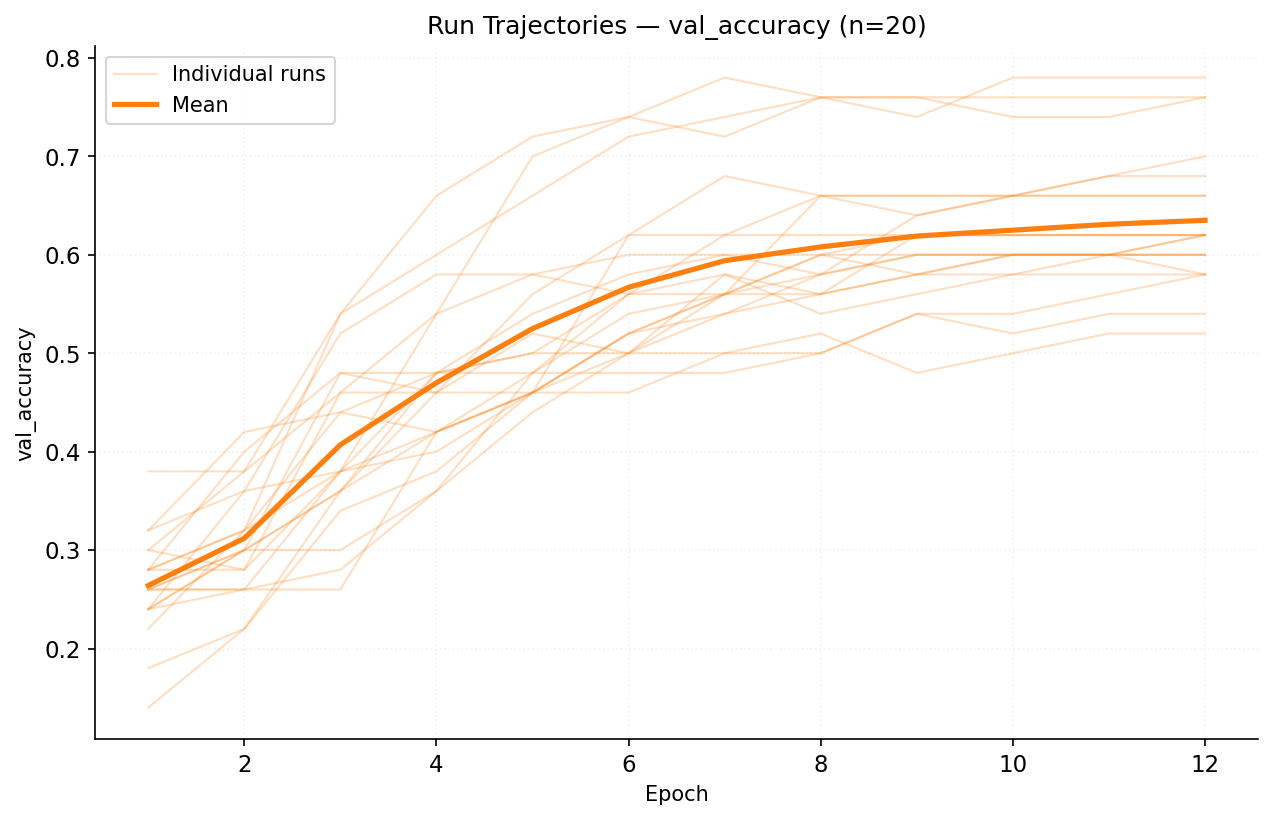

In [10]:
ix.plot_run_trajectories(results=results, metric='val_accuracy', show=False);

Over three epochs, most runs should climb from near-chance accuracy (~25% for 4 classes) toward whatever the model can actually achieve on this subsampled data. If any run plateaus at chance or diverges, that's a visible failure mode — and on transformer fine-tuning with small data, it happens. Seeing all five trajectories at once is the point: you can diagnose which runs trained successfully and which didn't.

## Rank correlation over epochs

The question "at what epoch does the final ranking of runs emerge?" is answered by `plot_rank_correlation_over_epoch()` — it plots the Spearman correlation between each epoch's run ranking and the final-epoch ranking. In a paper I'm currently writing, this is the headline figure for argument that transformer fine-tuning doesn't stabilize its run-ordering until well into training.

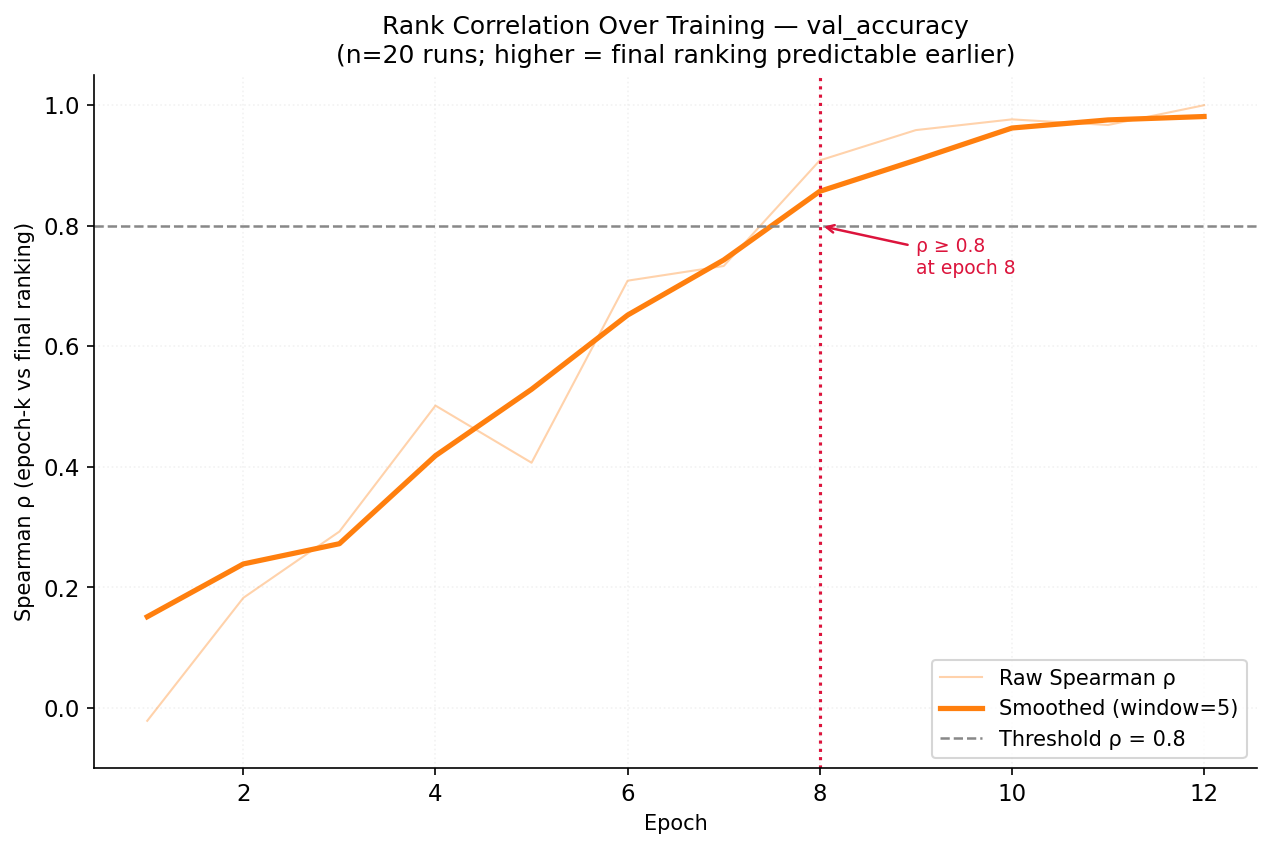

In [11]:
# Rank correlation requires more runs than 5 for a reliable plot;
# the function raises ValueError at n_runs < 15. At N=5 we'd skip this.
if len(test_accs) >= 15:
    ix.plot_rank_correlation_over_epoch(results=results, show=False)
else:
    print(f'Skipping rank correlation plot: need n_runs >= 15, have {len(test_accs)}.')

## Comparing two models: winner-reverses on transformers

To demonstrate `plot_paired_deltas()` on real transformer data, we run a second variability study with a different model and compare. Here we swap in `google/bert_uncased_L-2_H-128_A-2` for a slightly larger variant, `google/bert_uncased_L-4_H-256_A-4` (4 layers instead of 2, 256 hidden instead of 128). Same data, same seeds, same hyperparameters.

Because both studies use the same seed and same data handler, runs are pairable by index — run 1 of each used the same child seed. This is the paired comparison Ictonyx is designed for.

In [14]:
results_larger = ix.variability_study(
    model=HuggingFaceModelWrapper,
    model_kwargs={
        'model_name_or_path': 'google/bert_uncased_L-4_H-256_A-4',
        'num_labels': NUM_LABELS,
    },
    data=(train_texts, train_labels),
    validation_data=(test_texts, test_labels),
    runs=20,
    epochs=12,
    batch_size=16,
    learning_rate=5e-5,
    seed=2026,
)

print(results_larger.summarize())

Loading and preparing data...
Array splits - Train: 350, Val: 50, Test: 100
Data loaded successfully

Starting Variability Study
  Runs: 20
  Epochs per run: 12
  Execution mode: in standard mode
  Seed: 2026



Variability Study:   0%| | 0

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

{'eval_loss': '1.359', 'eval_accuracy': '0.36', 'eval_runtime': '0.0208', 'eval_samples_per_second': '2401', 'eval_steps_per_second': '192.1', 'epoch': '1'}
{'eval_loss': '1.27', 'eval_accuracy': '0.48', 'eval_runtime': '0.0189', 'eval_samples_per_second': '2649', 'eval_steps_per_second': '211.9', 'epoch': '2'}
{'loss': '1.328', 'grad_norm': '4.037', 'learning_rate': '1.814e-05', 'epoch': '2.273'}
{'eval_loss': '1.166', 'eval_accuracy': '0.7', 'eval_runtime': '0.0209', 'eval_samples_per_second': '2395', 'eval_steps_per_second': '191.6', 'epoch': '3'}
{'eval_loss': '1.079', 'eval_accuracy': '0.76', 'eval_runtime': '0.0199', 'eval_samples_per_second': '2518', 'eval_steps_per_second': '201.4', 'epoch': '4'}
{'loss': '1.112', 'grad_norm': '3.723', 'learning_rate': '1.392e-05', 'epoch': '4.545'}
{'eval_loss': '1.003', 'eval_accuracy': '0.78', 'eval_runtime': '0.0207', 'eval_samples_per_second': '2421', 'eval_steps_per_second': '193.7', 'epoch': '5'}
{'eval_loss': '0.941', 'eval_accuracy': '

Variability Study:   5%| | 1

...

Variability Study:  95%|▉| 1

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

{'eval_loss': '1.362', 'eval_accuracy': '0.32', 'eval_runtime': '0.0196', 'eval_samples_per_second': '2552', 'eval_steps_per_second': '204.2', 'epoch': '1'}
{'eval_loss': '1.255', 'eval_accuracy': '0.56', 'eval_runtime': '0.0209', 'eval_samples_per_second': '2391', 'eval_steps_per_second': '191.3', 'epoch': '2'}
{'loss': '1.341', 'grad_norm': '3.026', 'learning_rate': '1.814e-05', 'epoch': '2.273'}
{'eval_loss': '1.154', 'eval_accuracy': '0.66', 'eval_runtime': '0.0214', 'eval_samples_per_second': '2341', 'eval_steps_per_second': '187.3', 'epoch': '3'}
{'eval_loss': '1.071', 'eval_accuracy': '0.78', 'eval_runtime': '0.0218', 'eval_samples_per_second': '2299', 'eval_steps_per_second': '183.9', 'epoch': '4'}
{'loss': '1.113', 'grad_norm': '2.899', 'learning_rate': '1.392e-05', 'epoch': '4.545'}
{'eval_loss': '0.993', 'eval_accuracy': '0.78', 'eval_runtime': '0.0215', 'eval_samples_per_second': '2321', 'eval_steps_per_second': '185.6', 'epoch': '5'}
{'eval_loss': '0.9246', 'eval_accuracy'

Variability Study: 100%|█| 2


--------------------------------------------------

Study Summary:
  Successful runs: 20/20
  val_loss: 0.7873 (SD = 0.0280)
  val_accuracy: 0.7940 (SD = 0.0235)
  val_runtime: 0.0224 (SD = 0.0022)
  val_samples_per_second: 2246.5907 (SD = 203.4981)
  val_steps_per_second: 179.7272 (SD = 16.2799)
  train_loss: 0.9324 (SD = 0.0341)
Variability Study Results
Successful runs: 20
Seed: 2026

Test Set Metrics:
--------------------
accuracy:
  N:                20
  Mean:             0.8590
  SD (sample, N-1): 0.0234
  SE:               0.0052
  Min:              0.8100
  Max:              0.9100

Validation Metrics:
--------------------
train_loss:
  N:                20
  Mean:             0.9324
  SD (sample, N-1): 0.0341
  SE:               0.0076
  Min:              0.8780
  Max:              0.9930
val_accuracy:
  N:                20
  Mean:             0.7940
  SD (sample, N-1): 0.0235
  SE:               0.0053
  Min:              0.7400
  Max:              0.8400
val_loss:
  N:    

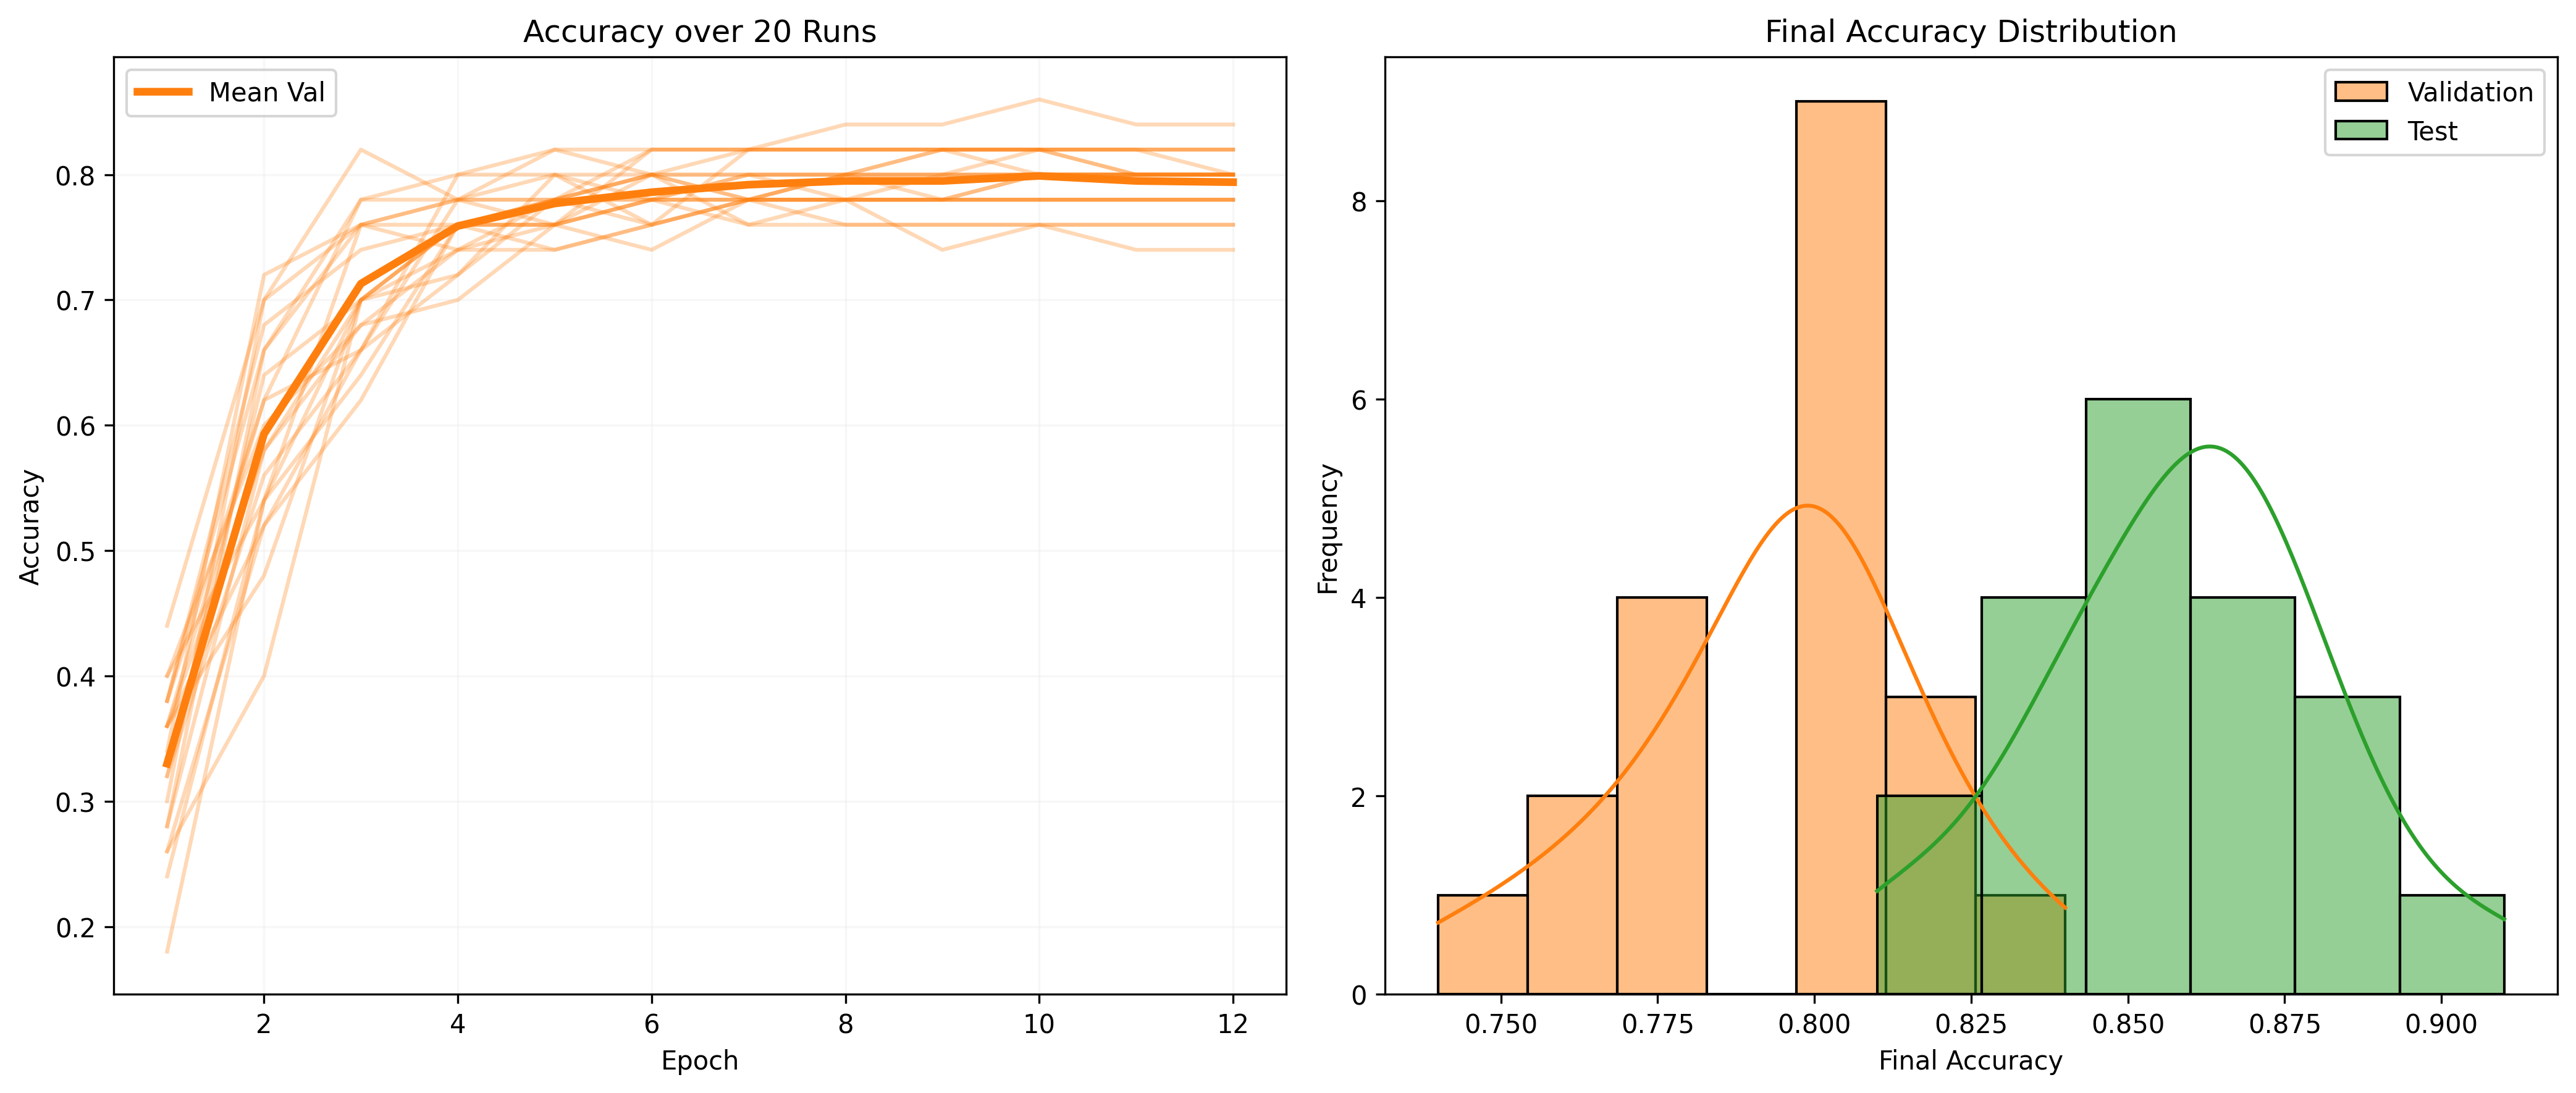

In [15]:
ix.plot_variability_summary(results=results_larger, metric='accuracy', show=False);

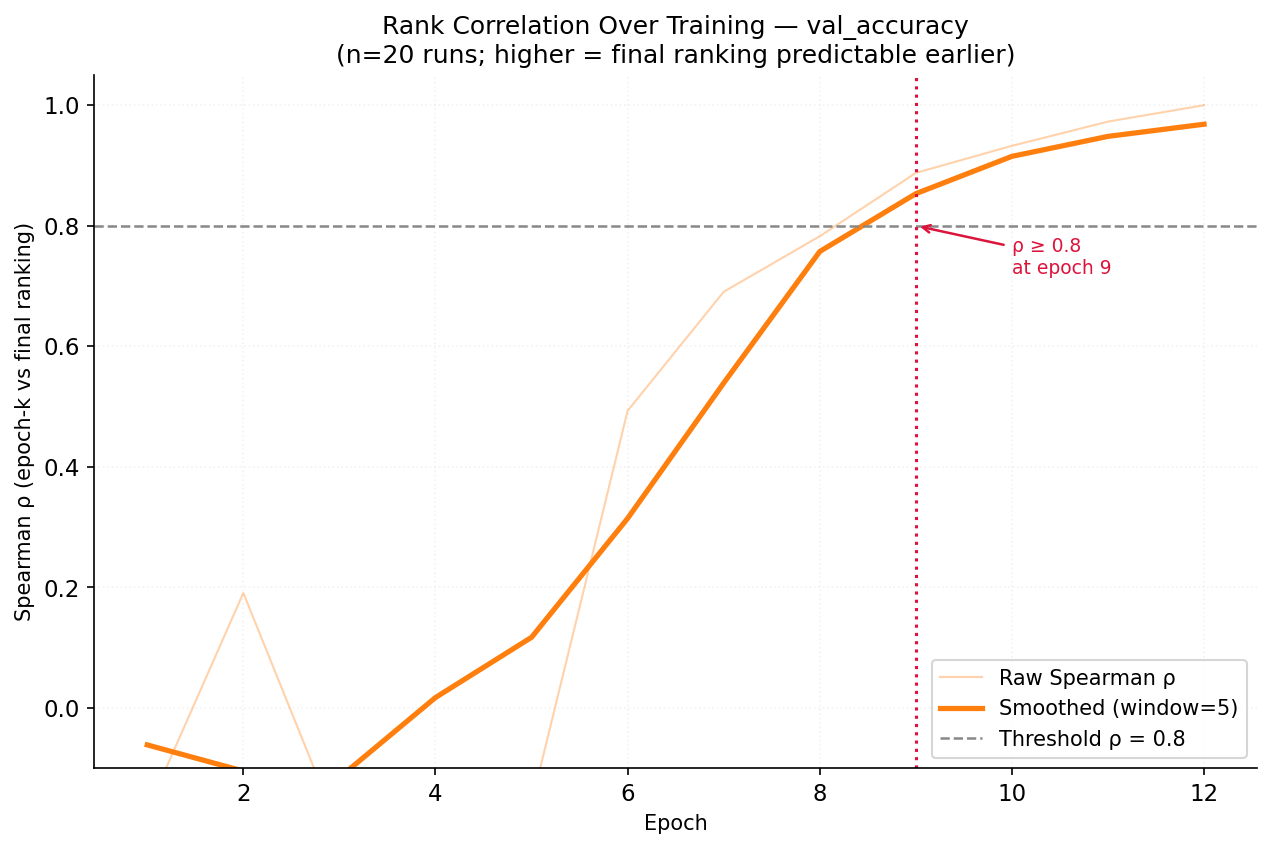

In [19]:
ix.plot_rank_correlation_over_epoch(results=results_larger, show=False);


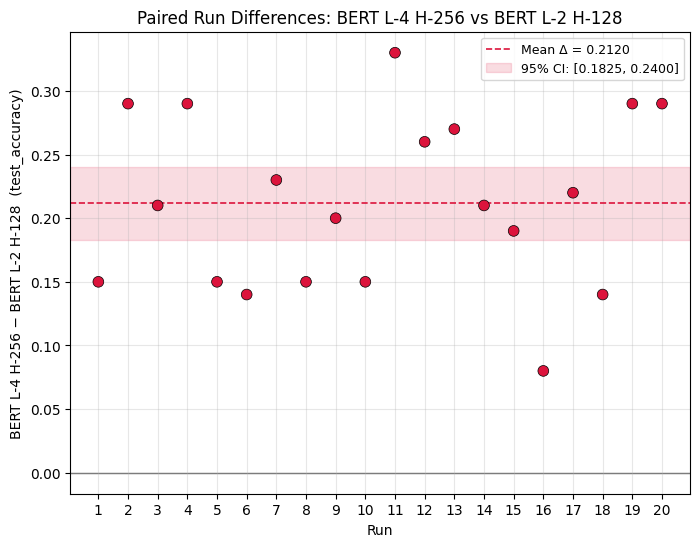

In [17]:
ix.plot_paired_deltas(
    results_larger,
    results,
    metric='test_accuracy',
    name_a='BERT L-4 H-256',
    name_b='BERT L-2 H-128',
    show=False,
);

On paired transformer data, you often see something the aggregate statistics hide: the larger model wins on *most* seeds but not *all* of them. That's the winner-reverses phenomenon. At N=5 the pattern is suggestive rather than conclusive; at N=20 on full AG News it becomes clearly visible and forms the heart of several recent variance-aware evaluation papers.

The paired comparison test quantifies it:

In [18]:
comparison = ix.compare_results(
    results_larger,
    results,
    paired=True,
    metric='test_accuracy',
)

test = comparison.overall_test
print(f'Test: {test.test_name}')
print(f'p-value: {test.p_value:.4f}')
if test.effect_size is not None:
    print(f'Effect size ({test.effect_size_name}): {test.effect_size:.3f}')
if test.conclusion:
    print(f'\nConclusion: {test.conclusion}')

Test: Paired Wilcoxon Signed-Rank Test
p-value: 0.0001
Effect size (r (effect size)): 0.877

Conclusion: Model A outperforms the other in paired comparison (W=0.000, p=0.0001, n=20 pairs).


## Summary

This notebook is the HuggingFace equivalent of the sklearn and PyTorch variability studies in `04_pytorch_classification.ipynb` and `06_sklearn_models.ipynb`. The API is the same: build a wrapper, hand it to `variability_study()`, inspect the distribution with Ictonyx's plotters. The thing to watch out for on HuggingFace specifically is that fine-tuning at small data is famously unstable.